## Chatbot sample

We'll use [LangGraph](https://langgraph.com) for building our agent's state machine and [Arize Phoenix](https://github.com/Arize-ai/phoenix) for logging and debugging.

Building a custom chatbot will allow for better flexibility in the later stage of development, to add prompt injection protection and other sports parsing.

In [4]:
!uv pip install langgraph


Audited 1 package in 4ms


Remember to use `phoenix serve` to launch the server.

In [5]:
!uv pip install openinference-instrumentation-langchain opentelemetry-api opentelemetry-instrumentation
!uv pip install arize-phoenix-otel

PHOENIX_COLLECTOR_ENDPOINT = "http://localhost:4317" # grpc endpoint for the Phoenix collector

from phoenix.otel import register

# configure the Phoenix tracer
tracer_provider = register(
  project_name="default", # Default is 'default'
  auto_instrument=True, # See 'Trace all calls made to a library' below
  endpoint=PHOENIX_COLLECTOR_ENDPOINT, # The Phoenix collector endpoint
)


Audited 3 packages in 3ms
Resolved 23 packages in 10ms                                         
Uninstalled 1 package in 3ms
Installed 1 package in 2ms                                  
 - protobuf==6.31.1
 + protobuf==5.29.5
🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {'user-agent': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [6]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
  messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [7]:
#!uv pip install import_ipynb
#import import_ipynb
#model = __import__("01_vanilla_prompt").get_model()

EDIT: phi4-mini is having some trouble with tool calls and we don't want to spend minutes running a better model, so we'll switch to Gemini.

In [14]:
!uv pip install -qU "langchain[google-genai]"

import getpass
import os
from langchain_google_genai import ChatGoogleGenerativeAI

if not os.environ.get("GOOGLE_API_KEY"):
  os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [9]:
def chatbot(state: State):
  return {"messages": [model.invoke(state["messages"])]}

In [10]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()


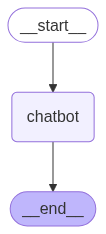

In [11]:
from IPython.display import Image, display

def draw_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

draw_graph(graph)

In [15]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What is 2 + 3?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Transient error StatusCode.UNAVAILABLE encountered while exporting traces to localhost:4317, retrying in 1s.


Assistant: Hi there! How can I help you today?


/Users/afonso/Developer/git/private/tonibot/ipynb/.venv/lib/python3.13/site-packages/langchain_google_genai/chat_models.py:1568: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


User: What is 2 + 3?
Assistant: 2 + 3 = 5


## With tool

Let's add the tool.

In [18]:
!uv pip install import_ipynb
import import_ipynb

add = __import__("01_vanilla_prompt").add
tools = [add]

model_with_tools = model.bind_tools(tools)

def chatbot_with_tools(state: State):
  return {"messages": [model_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot_with_tools", chatbot_with_tools)


Audited 1 package in 5ms
Audited 2 packages in 7ms


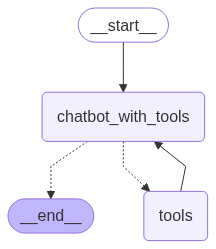

In [19]:
from langgraph.prebuilt import ToolNode, tools_condition
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "chatbot_with_tools")
graph_builder.add_conditional_edges("chatbot_with_tools", tools_condition, )
graph_builder.add_edge("tools", "chatbot_with_tools")

graph = graph_builder.compile()
draw_graph(graph)

In [20]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What is 2 + 3?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: 
Assistant: 42
Assistant: 39 + 3 is 42.
Goodbye!


TODO add memory and remaining missing functionality